In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

In [ ]:
file_path = '/content/drive/MyDrive/housewarming_posts_with_space_type.csv'
df = pd.read_csv(file_path)
df.head()

,contentId,contentType,title,createdAt,updatedAt,viewCount,likeCount,scrapCount,shareCount,commentAndReplyCount,...,features_budget,features_familyList,features_styleList,features_constructions,primary_tone,primary_ratio,secondary_tone,secondary_ratio,rating,space_type
0,193499,Project,맥시멀리스트의 취향에 따라 매일이 달라지는 8.5평 복층 오피스텔,2026-05-06T08:05:43.000+09:00,2026-05-06T08:05:43.000+09:00,249,2,9,0,0,...,0,"[""싱글라이프""]",[],[],Dark-Gray,0.513,Dark-Sky-Blue,0.217,NaN,TR
1,185117,Project,"낮엔 환하게, 밤엔 은은하게! 간접조명 활용은 이렇게",2026-05-06T08:05:42.000+09:00,2026-05-06T08:05:42.000+09:00,328,1,5,0,0,...,8000,"[""취학 자녀가 있는 집""]","[""미니멀&심플"", ""모던""]","[""주방리모델링"", ""조명시공"", ""중문"", ""도배시공"", ""필름시공"", ""바닥시공""]",Light-Gray,0.539,Medium-Gray,0.393,우수회원,RT
2,183328,Project,서울 맞나요? 숲 뷰가 액자처럼 들어오는 33평 집,2026-05-06T08:05:39.000+09:00,2026-05-06T08:05:39.000+09:00,502,1,5,2,0,...,7000,"[""취학 자녀가 있는 집""]","[""모던"", ""내추럴""]","[""주방리모델링"", ""아트월"", ""조명시공"", ""발코니확장"", ""중문"", ""도배시공...",Medium-Gray,0.687,Dull-Orange,0.164,우수회원,TR
3,195099,Project,"아이와 함께하는 일상도, 감각도 놓치지 않은 거실 7곳",2026-05-05T08:05:46.000+09:00,2026-05-05T08:05:46.000+09:00,990,6,23,3,0,...,0,"[""취학 자녀가 있는 집""]",[],[],Light-Gray,0.300,White,0.219,NaN,FR
4,194221,Project,"입주 6개월 차, '우리'의 분위기를 닮아가는 35평 신혼집",2026-05-05T08:05:45.000+09:00,2026-05-05T08:05:45.000+09:00,1234,21,37,5,22,...,3500,"[""신혼부부""]","[""모던""]",[],Dull-Orange,0.308,Medium-Gray,0.248,NaN,TR


In [ ]:
df.columns

Index(['contentId', 'contentType', 'title', 'createdAt', 'updatedAt',
       'viewCount', 'likeCount', 'scrapCount', 'shareCount',
       'commentAndReplyCount', 'writer_id', 'writer_userableType',
       'features_residence', 'features_area', 'features_agent',
       'features_expertise', 'features_region', 'features_budget',
       'features_familyList', 'features_styleList', 'features_constructions',
       'primary_tone', 'primary_ratio', 'secondary_tone', 'secondary_ratio',
       'rating', 'space_type'],
      dtype='object')

In [ ]:
space_dist = (
    df["space_type"]
    .dropna()   # 집계할 때만 NaN 제외
    .value_counts()
)

print(space_dist)

space_type
TR    1898
RT    1500
TH     847
TF     417
HT     348
RH     333
HR     324
RF     177
TT     172
FR     160
FT     153
RR      86
FH      55
HF      46
HH      26
FF      16
Name: count, dtype: int64


In [ ]:
(
df["space_type"]
.dropna()
.value_counts(normalize=True)
*100
).round(2)

,proportion
space_type,
TR,28.94
RT,22.87
TH,12.92
TF,6.36
HT,5.31
RH,5.08
HR,4.94
RF,2.70
TT,2.62


<Axes: xlabel='space_type'>

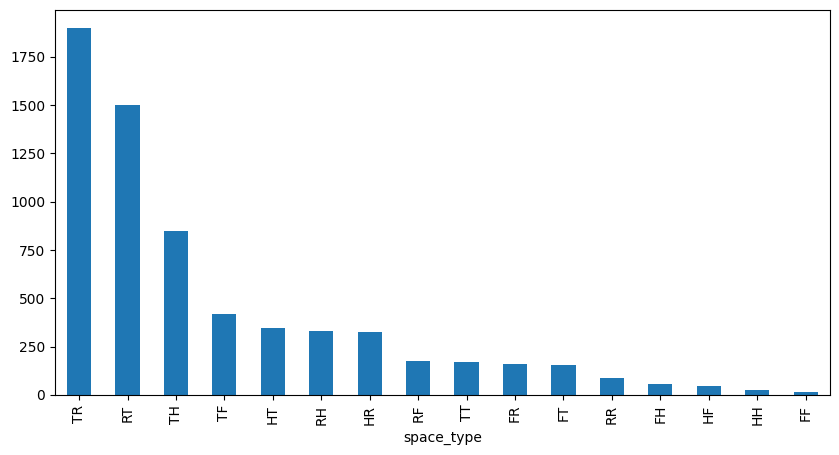

In [ ]:
space_dist = (
    df["space_type"]
    .dropna()
    .value_counts()
)

space_dist.plot(
    kind="bar",
    figsize=(10,5)
)

- 지배적인 공간 인식 유형은 TR
- 많은 사람들이 집을 취향을 드러내는 동시에 휴식을 취하는 공간으로 인식하고 있음을 알 수 있음.
- 상위 5개 유형에 모두 T가 포함됨.
- 집 = 자신의 취향을 구현/실현하는 공간이라는 인식이 지배적.
- 단일유형보다 복합유형의 비중이 더 높음.


# 1. 인기도 점수기반 공간유형별 상위 게시글 추출

In [ ]:
file_path = '/content/drive/MyDrive/housewarming_posts_with_space_type&url.csv'
df2 = pd.read_csv(file_path)
df2.head()

,contentId,contentType,title,createdAt,updatedAt,viewCount,likeCount,scrapCount,shareCount,commentAndReplyCount,...,features_familyList,features_styleList,features_constructions,primary_tone,primary_ratio,secondary_tone,secondary_ratio,rating,space_type,url
0,193499,Project,맥시멀리스트의 취향에 따라 매일이 달라지는 8.5평 복층 오피스텔,2026-05-06T08:05:43.000+09:00,2026-05-06T08:05:43.000+09:00,249,2,9,0,0,...,"[""싱글라이프""]",[],[],Dark-Gray,0.513,Dark-Sky-Blue,0.217,NaN,TR,https://contents.ohou.se/projects/193499
1,185117,Project,"낮엔 환하게, 밤엔 은은하게! 간접조명 활용은 이렇게",2026-05-06T08:05:42.000+09:00,2026-05-06T08:05:42.000+09:00,328,1,5,0,0,...,"[""취학 자녀가 있는 집""]","[""미니멀&심플"", ""모던""]","[""주방리모델링"", ""조명시공"", ""중문"", ""도배시공"", ""필름시공"", ""바닥시공""]",Light-Gray,0.539,Medium-Gray,0.393,우수회원,RT,https://contents.ohou.se/projects/185117
2,183328,Project,서울 맞나요? 숲 뷰가 액자처럼 들어오는 33평 집,2026-05-06T08:05:39.000+09:00,2026-05-06T08:05:39.000+09:00,502,1,5,2,0,...,"[""취학 자녀가 있는 집""]","[""모던"", ""내추럴""]","[""주방리모델링"", ""아트월"", ""조명시공"", ""발코니확장"", ""중문"", ""도배시공...",Medium-Gray,0.687,Dull-Orange,0.164,우수회원,TR,https://contents.ohou.se/projects/183328
3,195099,Project,"아이와 함께하는 일상도, 감각도 놓치지 않은 거실 7곳",2026-05-05T08:05:46.000+09:00,2026-05-05T08:05:46.000+09:00,990,6,23,3,0,...,"[""취학 자녀가 있는 집""]",[],[],Light-Gray,0.300,White,0.219,NaN,FR,https://contents.ohou.se/projects/195099
4,194221,Project,"입주 6개월 차, '우리'의 분위기를 닮아가는 35평 신혼집",2026-05-05T08:05:45.000+09:00,2026-05-05T08:05:45.000+09:00,1234,21,37,5,22,...,"[""신혼부부""]","[""모던""]",[],Dull-Orange,0.308,Medium-Gray,0.248,NaN,TR,https://contents.ohou.se/projects/194221


In [ ]:
df2.columns

Index(['contentId', 'contentType', 'title', 'createdAt', 'updatedAt',
       'viewCount', 'likeCount', 'scrapCount', 'shareCount',
       'commentAndReplyCount', 'writer_id', 'writer_userableType',
       'features_residence', 'features_area', 'features_agent',
       'features_expertise', 'features_region', 'features_budget',
       'features_familyList', 'features_styleList', 'features_constructions',
       'primary_tone', 'primary_ratio', 'secondary_tone', 'secondary_ratio',
       'rating', 'space_type', 'url'],
      dtype='object')

## 1) 인기도 점수

In [ ]:
tmp = df2.copy()

# --------------------------
# 1. scrapRate 생성
# --------------------------

tmp["scrapRate"] = (
    tmp["scrapCount"]
    /
    tmp["viewCount"]
)

tmp["scrapRate"] = (
    tmp["scrapRate"]
    .replace(
        [np.inf,-np.inf],
        np.nan
    )
    .fillna(0)
)

# --------------------------
# 2. 사용할 변수 표준화
# --------------------------

cols = [
    "scrapRate",
    "commentAndReplyCount",
    "shareCount",
    "likeCount",
    "scrapCount"
]

for col in cols:

    tmp[col+"_scaled"] = (

        tmp[col]

        -

        tmp[col].min()

    ) / (

        tmp[col].max()

        -

        tmp[col].min()

    )

# --------------------------
# 3. 인기도 점수 계산
# --------------------------

tmp["pop_score"] = (

0.312
*
tmp["scrapRate_scaled"]

+

0.249
*
tmp["commentAndReplyCount_scaled"]

+

0.184
*
tmp["shareCount_scaled"]

+

0.130
*
tmp["likeCount_scaled"]

+

0.125
*
tmp["scrapCount_scaled"]

)

# --------------------------
# 4. space_type별 TOP3 추출
# --------------------------

top_posts = (

tmp

.sort_values(
"pop_score",
ascending=False
)

.groupby(
"space_type"
)

.head(3)

[[
"space_type",
"title",
"url",
"pop_score"
]]

.reset_index(
drop=True
)

)

# 보기 좋게 점수 정리
top_posts["pop_score"] = (
top_posts["pop_score"]
.round(4)
)

display(
top_posts
)

# --------------------------
# 5. csv 저장
# --------------------------

save_path = (
"/content/drive/MyDrive/"
"space_type_top3_urls.csv"
)

top_posts.to_csv(

save_path,

index=False,

encoding="utf-8-sig"

)

print(
"저장 완료:"
)

print(
save_path
)

,space_type,title,url,pop_score
0,HR,"거실, 침실, 작업실 그리고 드레스룸까지 있는 1.5룸",https://contents.ohou.se/projects/118179,0.6851
1,RF,보기만 해도 시원한 수영장과 조경이 매력적인 단독주택,https://contents.ohou.se/projects/110550,0.5315
2,TR,"서울 도심 속 노후주택, 4색 정원으로 어디든 초록 뷰",https://contents.ohou.se/projects/147041,0.5059
3,TR,양개형 문과 가벽 창문 디테일 더한 15평 코지 홈!🤎,https://contents.ohou.se/projects/172134,0.5033
4,TR,버터크림 같이 몽글몽글한 디자이너의 원룸 스타일링,https://contents.ohou.se/projects/133617,0.4681
5,RT,좁은 방도 낭만있게! 응답하라 지브리 다락방🚪🗝,https://contents.ohou.se/projects/135761,0.4287
6,RT,다 같은 화이트가 아니야! 키치 잇템으로 매칭한 오피스텔,https://contents.ohou.se/projects/147863,0.4257
7,TH,블랙앤화이트 그리고 실버로 가득한 무채색 사랑꾼의 집,https://contents.ohou.se/projects/111864,0.4253
8,RT,"취향과 실용성으로 채운 7평 행복주택, 나만의 안식처",https://contents.ohou.se/projects/136992,0.4202
9,RR,"아늑함을 가득 담은, 디자이너의 5평 원룸 사용법🌿",https://contents.ohou.se/projects/131800,0.4001


저장 완료:
/content/drive/MyDrive/space_type_top3_urls.csv


In [ ]:
from IPython.display import display, HTML

# 점수 정리
top_posts["rank"] = (
top_posts
.groupby(
"space_type"
)
.cumcount()
+
1
)

emoji = {
1:"🥇",
2:"🥈",
3:"🥉"
}

html = ""

for st in sorted(
top_posts["space_type"].unique()
):

    temp = (
        top_posts[
            top_posts["space_type"]
            ==
            st
        ]
    )

    html += f"""
    <div style="
        border:2px solid #ddd;
        border-radius:15px;
        padding:18px;
        margin-bottom:20px;
    ">

    <h2>
    {st} 유형
    </h2>
    """

    for _, row in temp.iterrows():

        html += f"""

        <div style="
            margin-bottom:18px;
            padding:10px;
            background:#f8f8f8;
            border-radius:10px;
        ">

        <h4>
        {emoji[row['rank']]}
        인기도 {row['pop_score']:.1%}
        </h4>

        <b>
        {row['title']}
        </b>

        <br><br>

        <a
        href="{row['url']}"
        target="_blank"
        >
        게시글 보기
        </a>

        </div>

        """

    html += "</div>"

display(
HTML(html)
)

# 2. 공간 인식 유형별 TOP 인테리어 스타일


In [ ]:
import ast

tmp = df.copy()

# 문자열 리스트 → 실제 리스트 변환
tmp["features_styleList"] = (
    tmp["features_styleList"]
    .fillna("[]")
    .apply(
        lambda x:
        ast.literal_eval(x)
        if isinstance(x, str)
        else x
    )
)

# 스타일 분리
tmp = tmp.explode(
    "features_styleList"
)

# 공백 제거
tmp["features_styleList"] = (
    tmp["features_styleList"]
    .astype(str)
    .str.strip()
)

# NaN 제거
tmp = tmp[
    tmp["features_styleList"]
    != "nan"
]

In [ ]:
style_ratio = (

tmp

.groupby(
[
"space_type",
"features_styleList"
]
)

.size()

.reset_index(
name="cnt"
)

)

style_ratio["ratio"] = (

style_ratio["cnt"]

/

style_ratio.groupby(
"space_type"
)["cnt"]

.transform(
"sum"
)

)

style_ratio = (
style_ratio
.sort_values(
[
"space_type",
"ratio"
],
ascending=[
True,
False
]
)
)

style_ratio

,space_type,features_styleList,cnt,ratio
0,FF,내추럴,6,0.375000
1,FF,모던,5,0.312500
2,FF,미니멀&심플,4,0.250000
3,FF,북유럽,1,0.062500
4,FH,내추럴,36,0.580645
...,...,...,...,...
139,TT,클래식&앤틱,4,0.022222
133,TT,러블리&로맨틱,2,0.011111
136,TT,북유럽,2,0.011111
140,TT,프렌치&프로방스,2,0.011111


In [ ]:
top_style = (

style_ratio

.groupby(
"space_type"
)

.head(5)

)

for st in sorted(
top_style["space_type"].unique()
):

    print("\n")
    print("="*60)

    print(st)

    display(

        top_style[
            top_style[
                "space_type"
            ]
            ==
            st
        ][
[
"features_styleList",
"ratio"
]
]

    )



FF


,features_styleList,ratio
0,내추럴,0.3750
1,모던,0.3125
2,미니멀&심플,0.2500
3,북유럽,0.0625




FH


,features_styleList,ratio
4,내추럴,0.580645
5,모던,0.306452
6,미니멀&심플,0.032258
8,유니크&믹스매치,0.032258
7,빈티지&레트로,0.016129




FR


...

,features_styleList,ratio
110,내추럴,0.496081
112,모던,0.319149
115,빈티지&레트로,0.072788
116,유니크&믹스매치,0.051512
113,미니멀&심플,0.027996




TR


,features_styleList,ratio
121,내추럴,0.487464
123,모던,0.292189
126,빈티지&레트로,0.068467
127,유니크&믹스매치,0.066538
124,미니멀&심플,0.029894




TT


,features_styleList,ratio
134,모던,0.344444
132,내추럴,0.327778
138,유니크&믹스매치,0.100000
135,미니멀&심플,0.088889
137,빈티지&레트로,0.077778


- 공간 인식 유형별 인테리어 스타일은 유의미한 차이를 보이지 않음.
- 스타일 X 톤 조합을 묶어서 보는 게 나을 것 같음.

In [ ]:
# 스타일 + 톤 조합 만들기

tmp = df.copy()

import ast

tmp["features_styleList"] = (
    tmp["features_styleList"]
    .fillna("[]")
    .apply(
        lambda x:
        ast.literal_eval(x)
        if isinstance(x, str)
        else x
    )
)

tmp = tmp.explode("features_styleList")

# 조합 생성
tmp["style_tone"] = (

tmp["features_styleList"]

+

" | "

+

tmp["primary_tone"]

)

# 비율 계산
cross = (

tmp

.groupby(
[
"space_type",
"style_tone"
]
)

.size()

.reset_index(
name="cnt"
)

)

cross["ratio"] = (

cross["cnt"]

/

cross.groupby(
"space_type"
)["cnt"]

.transform(
"sum"
)

)

cross = (

cross

.sort_values(
[
"space_type",
"ratio"
],
ascending=[
True,
False
]
)

)

In [ ]:
for st in sorted(
    cross["space_type"].unique()
):

    print("\n")
    print("="*70)

    print(
        f"{st} 유형"
    )

    display(

        cross[
            cross["space_type"] == st
        ]

        .head(5)

        [[
            "style_tone",
            "cnt",
            "ratio"
        ]]

    )



FF 유형


,style_tone,cnt,ratio
1,내추럴 | Light-Gray,3,0.1875
5,모던 | Light-Gray,2,0.1250
10,미니멀&심플 | White,2,0.1250
0,내추럴 | Dull-Orange,1,0.0625
2,내추럴 | Medium-Gray,1,0.0625




FH 유형


,style_tone,cnt,ratio
15,내추럴 | Light-Gray,17,0.274194
22,모던 | Light-Gray,13,0.209677
16,내추럴 | Medium-Gray,7,0.112903
20,내추럴 | White,4,0.064516
23,모던 | Medium-Gray,3,0.048387




FR 유형


...

,style_tone,cnt,ratio
551,내추럴 | Light-Gray,212,0.237402
574,모던 | Light-Gray,127,0.142217
553,내추럴 | Medium-Gray,71,0.079507
575,모던 | Medium-Gray,63,0.070549
547,내추럴 | Dull-Orange,34,0.038074




TR 유형


,style_tone,cnt,ratio
640,내추럴 | Light-Gray,446,0.215043
670,모던 | Light-Gray,309,0.148987
643,내추럴 | Medium-Gray,197,0.094986
672,모던 | Medium-Gray,125,0.060270
637,내추럴 | Dull-Orange,73,0.035198




TT 유형


,style_tone,cnt,ratio
769,모던 | Light-Gray,29,0.161111
757,내추럴 | Light-Gray,28,0.155556
770,모던 | Medium-Gray,15,0.083333
758,내추럴 | Medium-Gray,10,0.055556
778,미니멀&심플 | Light-Gray,9,0.050000


# 3. 공간인식유형별 평수 구간 X 주거 형태

| 구간  | 평수     |
| --- | ------ |
| 초소형 | ~19평   |
| 소형  | 20~29평 |
| 중소형 | 30~39평 |
| 중형  | 40~49평 |
| 대형  | 50평+   |


In [ ]:
import pandas as pd
import numpy as np

# 평수 숫자 추출
df["area_num"] = (
    df["features_area"]
    .astype(str)
    .str.extract(r"(\d+)")
)

df["area_num"] = pd.to_numeric(
    df["area_num"],
    errors="coerce"
)

# 평수 구간화
bins = [
0,
19,
29,
39,
49,
999
]

labels = [
"초소형(10평대)",
"소형(20평대)",
"중소형(30평대)",
"중형(40평대)",
"대형(50평+)"
]

df["area_group"] = pd.cut(
    df["area_num"],
    bins=bins,
    labels=labels
)

# 분포 확인
print(
df["area_group"]
.value_counts()
)

area_group
중소형(30평대)    3030
소형(20평대)     2054
초소형(10평대)    1616
중형(40평대)      748
대형(50평+)      543
Name: count, dtype: int64


In [ ]:
area_dist = pd.crosstab(

df["space_type"],

df["area_group"],

normalize="index"

)

display(
(area_dist*100)
.round(1)
)

area_group,초소형(10평대),소형(20평대),중소형(30평대),중형(40평대),대형(50평+)
space_type,,,,,
FF,6.2,31.2,37.5,18.8,6.2
FH,0.0,23.6,45.5,16.4,14.5
FR,5.0,23.1,48.1,14.4,9.4
FT,2.6,15.7,54.9,12.4,14.4
HF,6.5,13.0,41.3,26.1,13.0
HH,38.5,15.4,38.5,0.0,7.7
HR,23.1,30.2,35.2,5.6,5.9
HT,17.3,35.2,34.6,8.6,4.3
RF,5.6,23.2,49.7,10.7,10.7


In [ ]:
for st in sorted(df["space_type"].dropna().unique()):

    print("\n")
    print("="*70)

    print(f"{st} 유형")

    temp = (
        area_dist
        .loc[st]
        .sort_values(
            ascending=False
        )
    )

    display(
        (
            temp*100
        )
        .round(1)
        .rename(
            "비율(%)"
        )
    )



FF 유형


,비율(%)
area_group,
중소형(30평대),37.5
소형(20평대),31.2
중형(40평대),18.8
초소형(10평대),6.2
대형(50평+),6.2




FH 유형


,비율(%)
area_group,
중소형(30평대),45.5
소형(20평대),23.6
중형(40평대),16.4
대형(50평+),14.5
초소형(10평대),0.0




FR 유형


...

,비율(%)
area_group,
중소형(30평대),39.9
소형(20평대),30.7
초소형(10평대),19.8
중형(40평대),5.5
대형(50평+),4.0




TR 유형


,비율(%)
area_group,
중소형(30평대),33.1
초소형(10평대),30.4
소형(20평대),27.0
중형(40평대),6.1
대형(50평+),3.4




TT 유형


,비율(%)
area_group,
초소형(10평대),35.7
중소형(30평대),31.0
소형(20평대),21.1
중형(40평대),7.0
대형(50평+),5.3


- 상식적으로는 넓은 평수 = 가족
- 작은 평수 = 1인 가구 or 신혼이라고 생각하지만 평수 컬럼만으로 알 수 없으니
- 주거형태랑 엮어서 봐야겠음.

In [ ]:
space_dist = pd.crosstab(

[
df["features_familyList"],
df["area_group"]
],

df["space_type"],

normalize="index"

)

display(
(space_dist*100)
.round(1)
)

space_type                       FF    FH    FR    FT   HF   HH    HR    HT  \
features_familyList area_group                                                
["기타"]              초소형(10평대)   0.0   0.0   1.3   0.0  0.6  0.0   6.3   7.6   
                    소형(20평대)    0.0   2.1   0.0   0.0  0.0  0.0   6.2  12.5   
                    중소형(30평대)   0.0   0.0   0.0   0.0  0.0  1.9   1.9   5.8   
                    중형(40평대)    0.0   0.0   0.0   0.0  0.0  0.0   9.5   0.0   
                    대형(50평+)    0.0   0.0   2.5   2.5  5.0  0.0   7.5   7.5   
["부모님과 함께 사는 집"]    초소형(10평대)   0.0   0.0   0.5   0.0  0.0  0.5   4.6   2.3   
                    소형(20평대)    0.0   0.0   0.0   0.0  0.0  0.0   0.0   0.0   
                    중소형(30평대)   0.0   0.0   2.3   0.0  0.0  2.3   4.5   4.5   
                    중형(40평대)    0.0   0.0   0.0   0.0  0.0  0.0  25.0   0.0   
                    대형(50평+)    0.0  11.8   5.9   0.0  0.0  0.0   0.0   0.0   
["신혼부부"]            초소형(10평대)   0.0   0.0   0.0   0.4  0.0  0.8   8.0   3.8   
                    소형(20평대)    0.2   0.2   0.3   0.0  0.1  0.2   6.0   8.0   
                    중소형(30평대)   0.1   0.3   0.2   0.2  0.4  0.4   6.5   7.1   
                    중형(40평대)    0.8   0.0   1.6   1.6  1.6  0.0   4.0  12.7   
                    대형(50평+)    0.0   0.0   0.0   0.0  0.0  0.0   7.5   7.5   
["싱글라이프"]           초소형(10평대)   0.0   0.0   0.0   0.1  0.0  0.8   3.8   3.1   
                    소형(20평대)    0.0   0.7   0.0   0.0  0.0  0.7   6.1   6.8   
                    중소형(30평대)   0.0   0.0   0.0   0.0  0.0  0.0  11.7   5.0   
                    중형(40평대)    0.0   0.0   0.0   0.0  0.0  0.0   0.0   0.0   
                    대형(50평+)    0.0   0.0  10.0   0.0  0.0  0.0   0.0  10.0   
["아기가 있는 집"]        초소형(10평대)   0.0   0.0   7.7   7.7  3.8  0.0   0.0  19.2   
                    소형(20평대)    0.4   3.4   9.1   9.1  0.9  0.0   3.9   3.4   
                    중소형(30평대)   0.3   2.3   6.5   8.9  1.3  0.2   2.4   2.9   
                    중형(40평대)    0.0   4.6   5.5   8.3  4.6  0.0   2.8   7.3   
                    대형(50평+)    0.0   2.5   5.1  13.9  2.5  1.3   3.8   2.5   
["취학 자녀가 있는 집"]     초소형(10평대)   6.2   0.0  18.8   0.0  6.2  0.0   0.0   0.0   
                    소형(20평대)    1.4   0.7   9.3   2.1  2.1  0.7   5.7   4.3   
                    중소형(30평대)   0.6   1.6   6.8   5.4  1.2  0.4   3.4   3.0   
                    중형(40평대)    1.0   2.0   7.4   3.9  2.5  0.0   2.5   3.0   
                    대형(50평+)    0.6   2.5   5.0   6.2  1.2  0.6   5.0   2.5   

space_type                        RF    RH    RR    RT    TF    TH    TR    TT  
features_familyList area_group                                                  
["기타"]              초소형(10평대)    0.6   7.6   3.8  25.3   1.3  13.3  29.1   3.2  
                    소형(20평대)     2.1  12.5   0.0  33.3   2.1   6.2  16.7   6.2  
                    중소형(30평대)    3.8   5.8   5.8  28.8   0.0  11.5  30.8   3.8  
                    중형(40평대)     0.0   0.0   9.5  28.6   0.0  23.8  23.8   4.8  
                    대형(50평+)     7.5   0.0  15.0  15.0   5.0  10.0  20.0   2.5  
["부모님과 함께 사는 집"]    초소형(10평대)    0.0   4.1   1.4  30.3   1.8  10.1  40.4   4.1  
                    소형(20평대)    12.5   0.0   0.0  37.5   0.0  12.5  37.5   0.0  
                    중소형(30평대)    4.5   2.3   2.3  34.1   2.3  15.9  20.5   4.5  
                    중형(40평대)     8.3   0.0   0.0  33.3   0.0   0.0  16.7  16.7  
                    대형(50평+)    11.8  17.6  11.8   5.9   0.0   5.9  29.4   0.0  
["신혼부부"]            초소형(10평대)    1.1   6.1   1.9  31.7   0.0  12.6  31.7   1.9  
                    소형(20평대)     1.1   7.1   1.0  21.5   1.8  17.9  32.4   2.2  
                    중소형(30평대)    1.1   5.5   1.1  21.4   1.8  20.6  31.7   1.7  
                    중형(40평대)     0.8   7.9   0.8  22.2   3.2  15.1  26.2   1.6  
                    대형(50평+)     3.0   7.5   1.5  29.9   1.5  17.9  20.9   3.0  
["싱글라이프"]           초소형(10평대)    0.4   5.6   2.1  29.2   1.0  10.0  39.2   4.7  
             

**인사이트 1. RT, TR이 거의 모든 조건에서 압도적**

거의 모든 그룹에서:

RT + TR ≈ 40~70%

수준임.

예시:

신혼부부 × 초소형 → RT 31.7%, TR 31.7%
싱글라이프 × 초소형 → RT 29.2%, TR 39.2%
취학 자녀 × 중형 → RT 24.6%, TR 24.1%
아기가 있는 집 × 중소형 → RT 15.6%, TR 21.1%

해석:

특정 유형이 일부 집단에서만 나타나는 게 아니라, 오늘의집 전반에서 RT·TR 계열 공간 인식이 기본적인 공간 인식 프레임으로 작동하고 있음.

**인사이트 2. 작은 공간일수록 TR·RT 집중 현상 발생**

특히:

싱글라이프 × 초소형
TR 39.2%
RT 29.2%
부모님과 거주 × 초소형
TR 40.4%
RT 30.3%
기타 × 초소형
TR 29.1%
RT 25.3%

해석:

제한된 면적에서는 다양한 기능보다 공간 효율성과 공간 활용 중심 인식이 강하게 나타남.

즉,

작은 공간
→ 공간 최적화
→ RT·TR 증가

**인사이트 3. 평수가 커질수록 유형 다양성이 증가함**

신혼부부 기준:

평수	상위 유형
초소형	RT, TR
중형	RT, TR, TH, HT
대형	RT, TR, TH 분산

아기가 있는 집도 비슷:

평수	특징
초소형	RT 집중
중형 이상	TF·TH·FT 증가

해석:

공간 여유가 생길수록 공간 인식 방식이 다양화됨.

**인사이트 4. 가족 성장 단계가 진행될수록 TF·FT가 증가**

아기가 있는 집:

TF
초소형 3.8%
중소형 20.6%
대형 26.6%

취학 자녀:

TF
초소형 0%
중소형 15.3%
대형 15.5%

해석:

자녀가 생길수록 공간 인식이 개인 중심보다 가족·생활 운영 중심으로 이동하는 경향.

In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd
import numpy as np

# 1. 교차표 생성
table = pd.crosstab(

[
df["features_familyList"],
df["area_group"]

],

df["space_type"]

)

print("교차표 크기:")
print(table.shape)

display(table)


# 2. 카이제곱 검정
chi2, p, dof, expected = chi2_contingency(table)


# 3. 효과크기 (Cramer's V)
n = table.sum().sum()

cramers_v = np.sqrt(
    chi2 /
    (
        n *
        (
            min(table.shape)-1
        )
    )
)


# 4. 기대빈도 조건 확인
expected_df = pd.DataFrame(
    expected,
    index=table.index,
    columns=table.columns
)

low_ratio = (
    (expected < 5)
    .sum()
    /
    expected.size
)


# 결과 출력
print("\n===== 카이제곱 검정 결과 =====")

print(f"Chi-square: {chi2:.2f}")
print(f"p-value: {p:.10f}")
print(f"자유도: {dof}")

print(f"\nCramer's V: {cramers_v:.3f}")

print(
f"기대빈도<5 비율: {low_ratio*100:.1f}%"
)


# 해석
print("\n===== 해석 =====")

if p < 0.05:
    print(
        "공간인식유형 분포 차이가 통계적으로 유의함"
    )

else:
    print(
        "유의한 차이를 확인하지 못함"
    )


if cramers_v < 0.1:
    print("효과크기: 매우 약함")

elif cramers_v < 0.3:
    print("효과크기: 약함")

elif cramers_v < 0.5:
    print("효과크기: 중간")

else:
    print("효과크기: 강함")

교차표 크기:
(30, 16)


space_type                      FF  FH  FR  FT  HF  HH  HR  HT  RF  RH  RR  \
features_familyList area_group                                               
["기타"]              초소형(10평대)    0   0   2   0   1   0  10  12   1  12   6   
                    소형(20평대)     0   1   0   0   0   0   3   6   1   6   0   
                    중소형(30평대)    0   0   0   0   0   1   1   3   2   3   3   
                    중형(40평대)     0   0   0   0   0   0   2   0   0   0   2   
                    대형(50평+)     0   0   1   1   2   0   3   3   3   0   6   
["부모님과 함께 사는 집"]    초소형(10평대)    0   0   1   0   0   1  10   5   0   9   3   
                    소형(20평대)     0   0   0   0   0   0   0   0   1   0   0   
                    중소형(30평대)    0   0   1   0   0   1   2   2   2   1   1   
                    중형(40평대)     0   0   0   0   0   0   3   0   1   0   0   
                    대형(50평+)     0   2   1   0   0   0   0   0   2   3   2   
["신혼부부"]            초소형(10평대)    0   0   0   1   0   2  21  10   3  16   5   
                    소형(20평대)     2   2   3   0   1   2  69  92  13  81  12   
                    중소형(30평대)    1   3   2   2   5   5  72  79  12  61  12   
                    중형(40평대)     1   0   2   2   2   0   5  16   1  10   1   
                    대형(50평+)     0   0   0   0   0   0   5   5   2   5   1   
["싱글라이프"]           초소형(10평대)    0   0   0   1   0   7  34  28   4  51  19   
                    소형(20평대)     0   1   0   0   0   1   9  10   0  11   2   
                    중소형(30평대)    0   0   0   0   0   0   7   3   1   3   1   
                    중형(40평대)     0   0   0   0   0   0   0   0   0   1   1   
                    대형(50평+)     0   0   1   0   0   0   0   1   0   1   0   
["아기가 있는 집"]        초소형(10평대)    0   0   2   2   1   0   0   5   2   0   0   
                    소형(20평대)     1   8  21  21   2   0   9   8  17   3   1   
                    중소형(30평대)    2  14  40  55   8   1  15  18  41  17   2   
                    중형(40평대)     0   5   6   9   5   0   3   8   7   2   0   
                    대형(50평+)     0   2   4  11   2   1   3   2   5   2   0   
["취학 자녀가 있는 집"]     초소형(10평대)    1   0   3   0   1   0   0   0   0   2   0   
                    소형(20평대)     2   1  13   3   3   1   8   6   9   4   1   
                    중소형(30평대)    3   8  34  27   6   2  17  15  30  14   1   
                    중형(40평대)     2   4  15   8   5   0   5   6  10   5   1   
                    대형(50평+)     1   4   8  10   2   1   8   4   7  10   2   

space_type                       RT   TF   TH   TR  TT  
features_familyList area_group                          
["기타"]              초소형(10평대)    40    2   21   46   5  
                    소형(20평대)     16    1    3    8   3  
                    중소형(30평대)    15    0    6   16   2  
                    중형(40평대)      6    0    5    5   1  
                    대형(50평+)      6    2    4    8   1  
["부모님과 함께 사는 집"]    초소형(10평대)    66    4   22   88   9  
                    소형(20평대)      3    0    1    3   0  
                    중소형(30평대)    15    1    7    9   2  
                    중형(40평대)      4    0    0    2   2  
                    대형(50평+)      1    0    1    5   0  
["신혼부부"]            초소형(10평대)    83    0   33   83   5  
                    소형(20평대)    247   21  206  372  25  
                    중소형(30평대)   238   20  230  353  19  
                    중형(40평대)     28    4   19   33   2  
                    대형(50평+)     20    1   12   14   2  
["싱글라이프"]           초소형(10평대)   264    9   90  354  42  
                    소형(20평대)     39    1   23   43   7  
                    중소형(30평대)    15    1   10   14   5  
                    중형(40평대)      1    0    2    4   2  
                    대형(50평+)      3    0    0    2   2  
["아기가 있는 집"]        초소형(10평대)     8    1    2    3   0  
                    소형(20평대)     40   34   14   53   0  
                    중소형(30평대)    97  128   42  131   9  
                    중형(40평대)     11   23    8   22   0  
                    대


===== 카이제곱 검정 결과 =====
Chi-square: 2432.27
p-value: 0.0000000000
자유도: 435

Cramer's V: 0.157
기대빈도<5 비율: 63.3%

===== 해석 =====
공간인식유형 분포 차이가 통계적으로 유의함
효과크기: 약함


In [ ]:
df["space_group"] = (
df["space_type"]
.str[0]
)

In [ ]:
table = pd.crosstab(
[
df["features_familyList"],
df["area_group"]
],
df["space_group"]
)

In [ ]:
from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

# 카이제곱 검정
chi2, p, dof, expected = chi2_contingency(table)

# Cramer's V
n = table.sum().sum()

cramers_v = np.sqrt(
    chi2 / (
        n * (min(table.shape) - 1)
    )
)

# 기대빈도 확인
expected_df = pd.DataFrame(
    expected,
    index=table.index,
    columns=table.columns
)

low_expected_ratio = (expected < 5).sum() / expected.size

print("===== 카이제곱 검정 결과 =====")
print(f"Chi-square: {chi2:.2f}")
print(f"p-value: {p:.10f}")
print(f"자유도: {dof}")
print(f"Cramer's V: {cramers_v:.3f}")
print(f"기대빈도 < 5 비율: {low_expected_ratio*100:.1f}%")

print("\n===== 해석 =====")

if p < 0.05:
    print("가족형태×평수 조합에 따라 공간인식 대분류 분포가 통계적으로 유의하게 다름")
else:
    print("통계적으로 유의한 차이를 확인하지 못함")

if cramers_v < 0.1:
    print("효과크기: 매우 약함")
elif cramers_v < 0.3:
    print("효과크기: 약함")
elif cramers_v < 0.5:
    print("효과크기: 중간")
else:
    print("효과크기: 강함")

===== 카이제곱 검정 결과 =====
Chi-square: 846.14
p-value: 0.0000000000
자유도: 87
Cramer's V: 0.208
기대빈도 < 5 비율: 25.0%

===== 해석 =====
가족형태×평수 조합에 따라 공간인식 대분류 분포가 통계적으로 유의하게 다름
효과크기: 약함


In [ ]:
file_path = '/content/drive/MyDrive/오늘의집_문장_라벨링.csv'
df2 = pd.read_csv(file_path)
df2.head()

,label,post_id,sentence_id,sentence,ai_label
0,NaN,20531,0,도면 <의뢰인 요청사항> Story 1.,5
1,NaN,20531,1,기존 거실 발코니 확장.,5
2,NaN,20531,2,Story 2.,5
3,NaN,20531,3,안방 폴딩도어 계획 및 발코니 좌식 평상 제작.,5
4,NaN,20531,4,Story 3.,5


In [ ]:
# label 컬럼 삭제
df2 = df2.drop(columns=['label'])

# ai_label → labels로 변경
df2 = df2.rename(columns={'ai_label': 'labels'})

# 확인
df2.head()

,post_id,sentence_id,sentence,labels
0,20531,0,도면 <의뢰인 요청사항> Story 1.,5
1,20531,1,기존 거실 발코니 확장.,5
2,20531,2,Story 2.,5
3,20531,3,안방 폴딩도어 계획 및 발코니 좌식 평상 제작.,5
4,20531,4,Story 3.,5


In [ ]:
# 1. 기본 확인
df2.info()
df2['labels'].value_counts().sort_index()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 878032 entries, 0 to 878031
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   post_id      878032 non-null  int64 
 1   sentence_id  878032 non-null  int64 
 2   sentence     878018 non-null  object
 3   labels       878032 non-null  object
dtypes: int64(2), object(2)
memory usage: 26.8+ MB


,count
labels,
0,23125
"0,1",24
"0,2",23
1,32714
"1,2",69
"1,4",1
2,8817
"2,4",10
4,15723


In [ ]:
# 데이터 복사
df_kw = df2.copy()

# 문자열 변환
df_kw['labels'] = df_kw['labels'].astype(str)

# 1. 멀티라벨 제거 (0,1 / 1,2 등)
df_kw = df_kw[
    ~df_kw['labels'].str.contains(',', na=False)
].copy()

# 2. label=5 제거 (무의미 제거)
df_kw = df_kw[
    df_kw['labels'] != '5'
].copy()

# 정수 변환
df_kw['labels'] = df_kw['labels'].astype(int)

# 필요한 컬럼만
df_kw = df_kw[
    ['post_id', 'sentence_id', 'sentence', 'labels']
]

# 결측 제거
df_kw = df_kw.dropna(
    subset=['sentence', 'labels']
)

# 확인
print(df_kw.shape)
print(df_kw['labels'].value_counts().sort_index())

(80377, 4)
labels
0    23125
1    32713
2     8817
4    15722
Name: count, dtype: int64


In [ ]:
!pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 18.6 MB/s eta 0:00:00


In [ ]:
# 불용어 추가
new_stopwords = [
    '주다',
    '싶다',
    '사용',
    '침실',
    '침대',
    '거실',
    '공간',
    '위해',
    '위해',
    '저희',
    '우리',
    '작다',
    '되다',
    '남편',
    '주방',
    '되어다',
    '인테리어',
    '조명',
    '가구',
    '크다',
    '작다',
    '드레스',
    '책상',
    '않다',
    '들다',
    '화이트',
    '수납',
    '방이',
    '방이',
    '안방',
    '테이블',
    '좋다',
    '좋아하다',
    '두다',
    '타일',
    '우드',
    '하나',
    '생각',
    '가장',
    '활용',
    '시간',
    '분위기',
    '안방'
]

stopwords.update(new_stopwords)

print(stopwords)

{'좋아하다', '위하다', '두다', '같다', '많다', '오늘', '테이블', '침실', '침대', '하지만', '보다', '작다', '가구', '싶다', '있다', '화이트', '남편', '분위기', '좋다', '이다', '하나', '하다', '주다', '부분', '안방', '수납', '우드', '타일', '정도', '없다', '크다', '공간', '생각', '책상', '그리고', '방이안방', '들다', '거실', '드레스', 'story', '주방', '인테리어', '가장', '사용', '위해', '되어다', '활용', '조명', '되다', '시간', '방이', '저희', '우리', '않다'}


In [ ]:
# 라벨별 최대 5000개씩 샘플링
df_sample = (
    df_kw
    .groupby('labels', group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), 5000), random_state=42))
)

print(df_sample['labels'].value_counts().sort_index())

labels
0    5000
1    5000
2    5000
4    5000
Name: count, dtype: int64


/tmp/ipykernel_1415/2931324875.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), 5000), random_state=42))


In [ ]:
from tqdm.notebook import tqdm
tqdm.pandas()

df_sample['tokens'] = df_sample['sentence'].progress_apply(extract_keywords)

  0%|          | 0/20000 [00:00<?, ?it/s]

In [ ]:
df_sample[['sentence', 'labels', 'tokens']].head()

,sentence,labels,tokens
646177,"작은 불빛 하나지만, 이 조명 덕분에 집에 들어오는 순간부터 아늑함과 따뜻함이 저희...",0,"[불빛, 덕분, 들어오다, 순간, 아늑하다, 따뜻하다, 감싸다, 펜던트, 센서, 고집]"
147743,공용 욕실은 아이들과 함께 사용하는 공간이라 화이트 톤과 그린 톤으로 밝고 경쾌한 ...,0,"[공용, 욕실, 아이, 그린, 밝다, 경쾌하다, 느낌, 여기다, 편안하다, 따뜻하다..."
702147,ㅎㅎ 커텐은 암막으로 설치해서 편안한 휴식 공간으로 만들어 보았습니다.,0,"[커텐, 설치, 편안하다, 휴식, 만들다]"
56904,저희는 오래 머물기에 가장 편안한 색이 '흰색'이라고 생각했습니다.,0,"[머물다, 편안하다, 흰색]"
184078,색감이 예뻐서 한동안 핸드폰 배경으로 설정해 놓았답니다 ;) 친구들이 놀러 와서 아...,0,"[색감, 예쁘다, 핸드폰, 배경, 설정, 놓다, 친구, 놀다, 오다, 아늑하다, 취..."


In [ ]:
df_label_doc = (
    df_sample
    .groupby('labels')['tokens']
    .apply(lambda x: ' '.join(sum(x, [])))
    .reset_index()
)

df_label_doc

,labels,tokens
0,0,불빛 덕분 들어오다 순간 아늑하다 따뜻하다 감싸다 펜던트 센서 고집 공용 욕실 아이...
1,1,작고 귀엽다 쫄깃 모닝 자주 만들다 애정 레드 체크 패턴 포인트 평소 미술관 갤러리...
2,2,잠귀 밝다 깊다 여전하다 둘째 칭얼거리다 깜짝 놀라다 아이 가보다 일쑤 수면 분리 ...
3,4,식탁 켜다 카페 무인양품 쉘프 함석 정리 커피 관련 용품 정리 걱정 달리 쉬다 분리...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(
    df_label_doc['tokens']
)

tfidf = pd.DataFrame(
    X.toarray(),
    index=df_label_doc['labels'],
    columns=vectorizer.get_feature_names_out()
)

tfidf.head()

,가가,가게,가격,가계부,가구라,가구장이,가구점,가기,가까워지다,가까이,...,힌진,힐링,힐링룸,힐즈,힘내다,힘드다,힘들다,힘쓰다,힘펠,힙하
labels,,,,,,,,,,,,,,,,,,,,,
0,0.000000,0.002318,0.002649,0.000000,0.000662,0.000000,0.000000,0.001655,0.000405,0.001987,...,0.000634,0.162233,0.000634,0.000000,0.000634,0.001655,0.005628,0.000000,0.000000,0.000000
1,0.000768,0.002404,0.019231,0.000605,0.000401,0.000768,0.000000,0.000401,0.000980,0.002404,...,0.000000,0.002003,0.000000,0.000768,0.000000,0.002805,0.014023,0.000000,0.000000,0.000000
2,0.000000,0.000811,0.002972,0.000000,0.001351,0.000000,0.000518,0.001621,0.000000,0.001081,...,0.000000,0.001891,0.000000,0.000000,0.000000,0.001621,0.004593,0.001035,0.000000,0.000000
4,0.000000,0.002954,0.002659,0.000446,0.000886,0.000000,0.000000,0.001477,0.000361,0.002659,...,0.000000,0.001182,0.000000,0.000000,0.000000,0.001477,0.003840,0.000000,0.000566,0.000566


In [ ]:
top_n = 10

keyword_dict = {}

for label in tfidf.index:

    keywords = (
        tfidf
        .loc[label]
        .sort_values(
            ascending=False
        )
        .head(top_n)
    )

    keyword_dict[label] = keywords

    print(f'\n===== LABEL {label} =====')
    display(keywords)


===== LABEL 0 =====


,0
편안하다,0.436150
아늑하다,0.413529
느낌,0.368501
따뜻하다,0.260235
포근하다,0.217468
자다,0.173490
힐링,0.162233
소파,0.153625
만들다,0.133759
안정감,0.120275



===== LABEL 1 =====


,1
포인트,0.505618
취향,0.283258
마음,0.229571
느낌,0.215949
컬러,0.209940
예쁘다,0.197519
자다,0.144634
통일,0.127005
깔끔하다,0.118992
꾸미다,0.112181



===== LABEL 2 =====


,2
아이방,0.671937
아이,0.571160
부부,0.179129
꾸미다,0.120500
가족,0.117798
만들다,0.108612
자다,0.078352
아기,0.068896
아지트,0.068407
서재,0.057818



===== LABEL 4 =====


,4
서재,0.755335
카페,0.378701
작업실,0.243113
만들다,0.148586
취미,0.109298
꾸미다,0.107821
홈바,0.094823
재택근무,0.077394
커피,0.070896
집사,0.066760


In [ ]:
keyword_table = pd.DataFrame({
    'labels': keyword_dict.keys(),
    'keywords': [
        ', '.join(v.index)
        for v in keyword_dict.values()
    ]
})

keyword_table

,labels,keywords
0,0,"편안하다, 아늑하다, 느낌, 따뜻하다, 포근하다, 자다, 힐링, 소파, 만들다, 안정감"
1,1,"포인트, 취향, 마음, 느낌, 컬러, 예쁘다, 자다, 통일, 깔끔하다, 꾸미다"
2,2,"아이방, 아이, 부부, 꾸미다, 가족, 만들다, 자다, 아기, 아지트, 서재"
3,4,"서재, 카페, 작업실, 만들다, 취미, 꾸미다, 홈바, 재택근무, 커피, 집사"


In [ ]:
from IPython.display import HTML, display

label_names = {
    0: "휴식형",
    1: "자기표현형",
    2: "관계형",
    4: "취미·작업형"
}

label_desc = {
    0: "공간을 휴식·안정·재충전의 장소로 인식",
    1: "공간을 취향·감성·개성을 표현하는 수단으로 인식",
    2: "공간을 가족·지인과 관계를 형성하는 장소로 인식",
    4: "공간을 취미·업무·집중 활동의 장소로 인식"
}

common_exclude = [
    '만들다', '꾸미다', '때문', '보인다',
    '선반', '장난감', '설치', '소개',
    '책장', '선택', '제품', '보이다',
    '배치', '시공', '쓰다'
]

exclude_by_label = {
    0: ['소파', '만들다', '꾸미다'],
    1: ['선택', '제품', '자다','서재'],
    2: ['장난감', '설치', '자다', '소개', '책장', '만들다', '꾸미다', '때문', '보인다', '쓰다','서재','욕실'],
    4: ['꾸미다', '아이', '자다', '선반', '집사']
}

top_n_by_label = {
    0: 10,
    1: 10,
    2: 7,
    4: 9
}

manual_add = {
    2: ['집들이', '함께','반려동물'],
    4: ['요리']
}

cards = ""

for label in tfidf.index:

    exclude_words = exclude_by_label.get(label, []) + common_exclude

    n = top_n_by_label.get(label, 10)

    top_words = (
        tfidf.loc[label]
        .drop(labels=exclude_words, errors='ignore')
        .sort_values(ascending=False)
        .head(n)
    )

    if label in manual_add:
        for word in manual_add[label]:
            top_words.loc[word] = 999

    top_words = top_words[~top_words.index.duplicated()]

    tags = ""

    for word in top_words.index:
        tags += f"""
        <span class="tag">{word}</span>
        """

    cards += f"""
    <div class="card">
        <div class="badge">LABEL {label}</div>
        <div class="title">{label_names[label]}</div>
        <div class="desc">{label_desc[label]}</div>
        <div class="keyword-box">
            {tags}
        </div>
    </div>
    """

html = """
<style>
.wrapper{
    max-width:1400px;
    margin:auto;
    padding:20px;
    font-family:Arial;
}

.main{
    font-size:36px;
    font-weight:800;
    margin-bottom:10px;
}

.sub{
    color:#666;
    margin-bottom:40px;
}

.grid{
    display:grid;
    grid-template-columns:1fr 1fr;
    gap:24px;
}

.card{
    background:white;
    padding:28px;
    border-radius:24px;
    box-shadow:0 8px 30px rgba(0,0,0,.08);
}

.badge{
    display:inline-block;
    padding:6px 12px;
    background:#eef4ff;
    color:#2b66ff;
    border-radius:999px;
    font-size:12px;
    font-weight:700;
}

.title{
    font-size:28px;
    font-weight:800;
    margin-top:14px;
}

.desc{
    margin-top:10px;
    color:#666;
    line-height:1.6;
}

.keyword-box{
    margin-top:28px;
    display:flex;
    flex-wrap:wrap;
    gap:10px;
}

.tag{
    background:linear-gradient(135deg, #edf4ff, #f8fbff);
    padding:10px 14px;
    border-radius:999px;
    color:#2054d4;
    font-weight:600;
    font-size:15px;
}
</style>

<div class='wrapper'>
    <div class='main'>🏠 공간인식유형별 대표 키워드</div>
    <div class='sub'>명사 + 동사 + 형용사 기반 TF-IDF 상위 키워드</div>
    <div class='grid'>
""" + cards + """
    </div>
</div>
"""

display(HTML(html))